# Import and Setup

In [40]:
# define logging and working directory
from ProjectRoot import change_wd_to_project_root
change_wd_to_project_root()
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import random
from collections import Counter
import matplotlib.pyplot as plt
#plt.rcParams.update({'font.size': 30})
import pandas as pd
import numpy as np
import SimpleITK as sitk 
import csv

import scipy.interpolate
from scipy.interpolate import interp1d


from src.utils.Notebook_imports import *
from src.data.Preprocess import clip_quantile
from src.data.Dataset import load_phase_reg_exp
from src.visualization.Visualize import plot_dir_norm
from src.visualization.Visualize import show_2D_or_3D

import tensorflow as tf
from src.models.KerasLayers import get_angle_tf,get_focus_tf,get_idxs_tf, minmax_lambda, flow2direction_lambda

from ipywidgets import interact, interact_manual
import ipywidgets as widgets
from IPython.core.display import display, HTML
from ipyfilechooser import FileChooser

%matplotlib inline
%reload_ext autoreload
%autoreload 2

search for root_dir and set working directory
Working directory set to: /mnt/ssd/sarah/git/cmr-multi-view-phase-detection


/tmp/ipykernel_1109412/2798601717.py:32: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [41]:
def get_file(path):
    files = sorted(glob.glob(path))
    if len(files) > 0:
        print(f"Found {len(files)} file in {path}.\nFirst file:{files[0]}\n")
    else:
        print(f"Found no files in {path}")
    return files

def get_df(path_chooser, file_name='dataset_information.csv'):
    dataset_path = path_chooser.selected
    dataset_info_path = get_file(os.path.join(dataset_path, file_name))
    df = pd.read_csv(dataset_info_path[0])
    # Find the first row with NaN values
    index_of_nan = df.index[df.isnull().any(axis=1)].tolist()

    # Stop reading at the first row with NaN values
    if index_of_nan:
        df = df.iloc[:index_of_nan[0]]
    return df

In [42]:
from src.visualization.Visualize import plot_pfd_per_phase_as_violin
def plot_error_as_violin(df_, exp_path = None, y_range=[0,10], plot = True):
    import seaborn as sb
    if type(y_range) == type(1):
        y_range = [0, y_range]
    sb.set_context('paper')
    sb.set(font_scale=2)
    if plot:
        # _ = df_.plot(kind='box')
        ax = sb.violinplot(data=df_)
        ax = sb.stripplot(data=df_, ax=ax)
        ax.set_ylim(y_range[0], y_range[1])
        _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    if y_range[1] - y_range[0] < 5: 
        pd.options.display.float_format = "{:,.4f}".format
    else: 
        pd.options.display.float_format = "{:,.2f}".format
    df_summarized = pd.concat([df_.mean(axis=0), df_.std(axis=0), df_.median(axis=0)], axis=1)
    df_summarized.columns = ['mean', 'SD', 'median']
    if plot:
        print('mean overall\n', df_summarized.mean())
        # print('mean first three phases\n',df_summarized.iloc[:3].mean())
        print(df_summarized)
        latex_output = " & ".join([f"{df_summarized.loc[col, 'mean']:.2f} $\\pm$ {df_summarized.loc[col, 'SD']:.2f}" for col in df_summarized.index]) + " \\\\"
        print("\nLaTeX Output:\n", latex_output)  # Output the formatted line
    
    if exp_path is not None: plt.savefig(os.path.join(exp_path, 'pFD_violin.png'))
    return df_summarized

## Select path to dataset

In [7]:
path_chooser_dataset = FileChooser(os.path.join(os.getcwd(),''), '')
display(path_chooser_dataset)

FileChooser(path='/mnt/ssd/sarah/git/cmr-multi-view-phase-detection', filename='', title='', show_hidden=False…

In [25]:
dataset_df_str = "dataset_information.csv"

dataset_path = path_chooser_dataset.selected

dataset_info_df = get_df(path_chooser_dataset, file_name=dataset_df_str)
dataset_info_df.columns = dataset_info_df.columns.str.lower()
dataset_info_df

Found 1 file in /mnt/ssd/sarah/data/mnm2/imported_LAX_2D_split/inference/dataset_information.csv.
First file:/mnt/ssd/sarah/data/mnm2/imported_LAX_2D_split/inference/dataset_information.csv



,subject_code,disease,vendor,scanner,field
0,201,NOR,SIEMENS,SymphonyTim,1.50
1,202,NOR,SIEMENS,SymphonyTim,1.50
2,203,NOR,Philips Medical Systems,Achieva,1.50
3,204,NOR,Philips Medical Systems,Achieva,1.50
4,205,NOR,Philips Medical Systems,Achieva,1.50
...,...,...,...,...,...
155,356,TRI,SIEMENS,Symphony,1.50
156,357,TRI,SIEMENS,SymphonyTim,1.50
157,358,TRI,SIEMENS,Symphony,1.50
158,359,TRI,SIEMENS,SymphonyTim,1.50


## Select path to model/experiment

In [21]:
path_chooser = FileChooser(os.path.join(os.getcwd(),''), '')
display(path_chooser)

FileChooser(path='/mnt/ssd/sarah/git/cmr-multi-view-phase-detection', filename='', title='', show_hidden=False…

In [26]:
model_path = path_chooser.selected
cfd_path = get_file(os.path.join(model_path, 'cfd.csv'))
gt_path = get_file(os.path.join(model_path, 'gt_phases.csv'))
pred_path = get_file(os.path.join(model_path, 'pred_phases.csv'))

gt_df = pd.read_csv(gt_path[0])
cfd_df = pd.read_csv(cfd_path[0])
pred_df = pd.read_csv(pred_path[0])

Found 1 file in /mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/cfd.csv.
First file:/mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/cfd.csv

Found 1 file in /mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/gt_phases.csv.
First file:/mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/gt_phases.csv

Found 1 file in /mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/pred_phases.csv.
First file:/mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/pred_phases.csv



mean overall
 mean     1.00
SD       1.09
median   1.00
dtype: float64
    mean   SD  median
ED  0.95 1.05    1.00
ES  1.06 1.12    1.00

LaTeX Output:
 0.95 $\pm$ 1.05 & 1.06 $\pm$ 1.12 \\


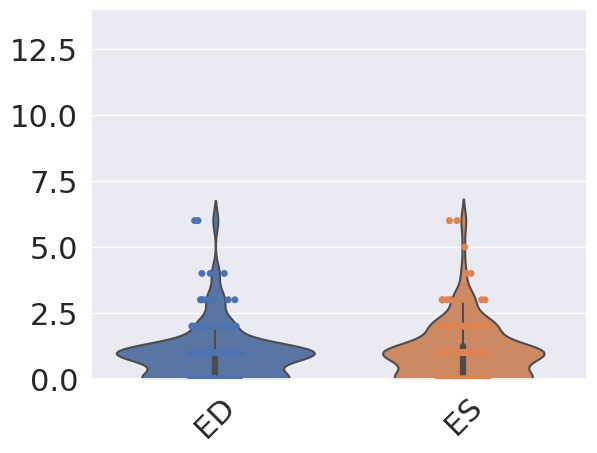

In [27]:
# If you have already a cfd file with results in the folder you can create violin plots of  wished phases here
phases = ['ED',  'ES']  #  ['ED', 'MS', 'ES', 'PF', 'MD'] or ['ED', 'ES']
plot_error_as_violin(cfd_df[phases], y_range= 14)
plt.show()

In [28]:
# Calculate avergae frame distance instead of the cyclic/periodic frame difference
def get_avg_fd(gt, pred):
    return abs(gt-pred)

aFD = []
for gt, pred in zip (gt_df['ED'], pred_df['ED']):
    aFD.append(get_avg_fd(gt,pred))
    
print(np.mean(np.array(aFD)))

               
print(gt_df)
print(pred_df)

9.25625
     ED  MS  ES  PF  MD                 patient
0    24   3   9  12  21  0_201_LA_CINE.nii.gz\n
1     0   4   9  13  22  0_202_LA_CINE.nii.gz\n
2     0   4   8  10  17  0_203_LA_CINE.nii.gz\n
3     0   4   9  12  20  0_204_LA_CINE.nii.gz\n
4     0   5   8  11  16  0_205_LA_CINE.nii.gz\n
..   ..  ..  ..  ..  ..                     ...
155  24   3   9  14  21  0_356_LA_CINE.nii.gz\n
156   4   6  16  21   0  0_357_LA_CINE.nii.gz\n
157   1   2  10  16  20  0_358_LA_CINE.nii.gz\n
158  24   3  11  15  19  0_359_LA_CINE.nii.gz\n
159  24   3   8  15  19  0_360_LA_CINE.nii.gz\n

[160 rows x 6 columns]
     Unnamed: 0  ED  MS  ES  PF  MD                 patient
0             0  24   3   9  13  21  0_201_LA_CINE.nii.gz\n
1             1  24   2   8  13  22  0_202_LA_CINE.nii.gz\n
2             2  19   3   7  11  17  0_203_LA_CINE.nii.gz\n
3             3  23   4   8  14  20  0_204_LA_CINE.nii.gz\n
4             4  20   3   8  12  16  0_205_LA_CINE.nii.gz\n
..          ...  ..  ..  ..  .. 

# Dataset analysis

In [17]:
dataset_gt_path = get_file(os.path.join(dataset_path, 'phases.csv'))
dataset_gt_df = get_df(path_chooser_dataset, 'phases.csv')

Found 1 file in /mnt/ssd/sarah/data/mnm2/imported_LAX_2D_split/inference/phases.csv.
First file:/mnt/ssd/sarah/data/mnm2/imported_LAX_2D_split/inference/phases.csv

Found 1 file in /mnt/ssd/sarah/data/mnm2/imported_LAX_2D_split/inference/phases.csv.
First file:/mnt/ssd/sarah/data/mnm2/imported_LAX_2D_split/inference/phases.csv



mean overall
 mean     10.09
SD        1.39
median   10.00
dtype: float64
    mean   SD  median
ED  0.00 0.00    0.00
MS  3.64 1.13    4.00
ES 10.37 1.72   10.00
PF 14.93 2.27   15.00
MD 21.52 1.85   21.00

LaTeX Output:
 0.00 $\pm$ 0.00 & 3.64 $\pm$ 1.13 & 10.37 $\pm$ 1.72 & 14.93 $\pm$ 2.27 & 21.52 $\pm$ 1.85 \\


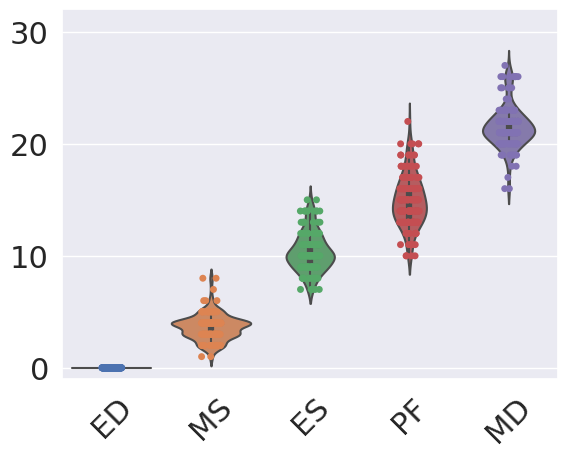

In [43]:
# Aligne phases at ED groundtruth and to show distribution of phases

def shift_and_scale(row, length):
    ed_idx =  length - row['ED#']
    shift = -ed_idx if ed_idx < length/2 else row['ED#']
    shifted = row - shift
    shifted = shifted % length
    return shifted

phases = ['ED#', 'MS#', 'ES#', 'PF#', 'MD#']
dataset_gt_df = dataset_gt_df[phases].astype(int)
df_transformed = dataset_gt_df.copy()
for idx in range(len(dataset_gt_df)):
    df_transformed.iloc[idx] = shift_and_scale(dataset_gt_df.iloc[idx], dataset_info_ext_df.loc[idx, 'lax sequence length'])

phases = ['ED', 'MS', 'ES', 'PF', 'MD'] #  ['ED', 'MS', 'ES', 'PF', 'MD'] or ['ED', 'ES']
df_transformed = df_transformed.rename(columns={'ED#': 'ED', 'MS#': 'MS', 'ES#': 'ES', 'PF#': 'PF', 'MD#': 'MD'})
plot_error_as_violin(df_transformed[phases], y_range= [-1, 32])
plt.show()

# Predict
Select a path, where you want to store the experiment.
You can either use the dataset.json given in the fold folder or redefine the parameters here in dataset_json for a new experiment.

In [30]:
# Select path, where you want to store your experiment
path_chooser_exp = FileChooser(os.path.join(os.getcwd(),''), '')
display(path_chooser_exp)

FileChooser(path='/mnt/ssd/sarah/git/cmr-multi-view-phase-detection', filename='', title='', show_hidden=False…

In [36]:
from src.utils.Utils_io import get_json
exp_root = path_chooser_exp.selected
cfg_files = get_json('config/config.json', model_path)

num_examples = 0 # Define, how many examples per junk of 10 you want to export as nrrd

Config file: ['/mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/f0/config/config.json']


In [44]:
# Adjust parameter, if you want to create a new experiment with post-processing settings
dataset_dict = { "channel_names": {"0": "cineMRI"}, 
                "labels": { 
                    "background": 0,
                    "LV": 1,
                    "MYO": 2,
                    "RV": 3
                }, 
                "suffix": {
                    "image_suffix": "CINE",
                    "mask_suffix": "", 
                    "file_ending": ".nii.gz"
                },
                "view":"LAX",
                "use_segmentation": False,
                "start_id": 0,
                "post_processing":{
                    "focus_point": "MSE",
                    "norm_threshold": 40,
                    "cc_filter": None,
                    "use_segmentation": False,
                    "mask_channels": None
         }
     }

# select here which dataset.json definition you want to use
# dataset_files = get_json('config/dataset.json', model_path  ) # dataset.json as stored in the subfolder config of the experiment.
# dataset_files = get_json('config/dataset.json', exp_root  ) # dataset.json as stored in the experiments folder (from older experiments).
dataset_files = [dataset_dict for idx in enumerate(cfg_files)] # dataset.json as given above in dataset_dict

In [48]:
from src.models.predict_phase_reg_model import CMRPhaseDetector

# predict for each fold
for cfg, data_json in zip(cfg_files, dataset_files):
    cmr_phase_predictor = CMRPhaseDetector(model_config=cfg, data_info_path=data_json, data_root=dataset_path, exp_path=model_path)
    cmr_phase_predictor.predict(number_of_examples=num_examples)

2025-09-18 14:47:31,336 INFO -------------------- Start --------------------
2025-09-18 14:47:31,337 INFO Working directory: /mnt/ssd/sarah/git/cmr-multi-view-phase-detection.
2025-09-18 14:47:31,337 INFO Log file: ./logs/media_mm2_288/phase_regression/f0.log
2025-09-18 14:47:31,337 INFO Log level for console: INFO
2025-09-18 14:47:31,337 INFO Loaded config for experiment: media_mm2_288/phase_regression/f0
2025-09-18 14:47:31,338 INFO No dataframe for splitting provided. Will use all files for train and validation
2025-09-18 14:47:31,338 INFO Selected 160 of 160 files
2025-09-18 14:47:31,338 INFO LAX train CMR: 160, LAXtrain masks: 160
2025-09-18 14:47:31,338 INFO LAX val CMR: 160, LAX val masks: 160
2025-09-18 14:47:31,338 INFO Split into chunks of:
2025-09-18 14:47:31,338 INFO LAX train CMR: 16, LAX train masks: 16
2025-09-18 14:47:31,338 INFO LAX val CMR: 16, LAX val masks: 16
2025-09-18 14:47:31,534 INFO Loading unet for use_segmentation from "/mnt/ssd/sarah/git/cmr-multi-view-phas

search for root_dir and set working directory
Working directory set to: /mnt/ssd/sarah/git/cmr-multi-view-phase-detection
['/gpu:0']
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
build u-net for input shape:  (None, 288, 288, 2)
Shape Input Tensor: (None, 40, 288, 288, 2)
Unet output shape: (None, 40, 288, 288, 16)
Flowfield shape: (None, 40, 288, 288, 2)


2025-09-18 14:47:32,802 INFO Trying to load the model weights
2025-09-18 14:47:32,802 INFO work dir: /mnt/ssd/sarah/git/cmr-multi-view-phase-detection
2025-09-18 14:47:32,802 INFO model weights dir: /mnt/ssd/sarah/git/cmr-multi-view-phase-detection/exp/exampleProject-LAX-Seg/f0/model/model.h5


Transformed shape : (None, 40, 288, 288, 1)
Segmentation shape: (None, 40, 1, 288, 288, 3)
flow features inkl directions shape: (None, 40, 288, 288, 1)
flow features after downsample/gap layer: (None, 40, 1)
Shape after final conv layer: (None, 40, 5)
added loss: ssim


2025-09-18 14:47:32,839 INFO loaded model weights as h5 file
2025-09-18 14:47:32,839 INFO ***********  processing junk: 0 of 16
2025-09-18 14:47:32,839 INFO Create DataGenerator
2025-09-18 14:47:32,839 INFO Datagenerator created with: 
 shape: [288, 288]
 spacing: [1.0, 1.0]
 batchsize: 1
 Scaler: standard
 Images: 10 
 Augment: False 
 Thread workers: 12
2025-09-18 14:47:32,839 INFO No augmentation
2025-09-18 14:47:32,839 INFO first file: /mnt/ssd/sarah/data/mnm2/imported_lax_2d_split/inference/lax/201_la_cine.nii.gz
2025-09-18 14:47:32,841 INFO Temporal phase augmentation: 
False
Repeat volume: 
True
2025-09-18 14:47:32,841 INFO params of generator:
2025-09-18 14:47:32,841 INFO [('MASKING_IMAGE', False), ('SINGLE_OUTPUT', False), ('MASKING_VALUES', [1, 2, 3]), ('DEBUG_MODE', False), ('SCALER', 'standard'), ('AUGMENT', False), ('SHUFFLE', False), ('RESAMPLE', True), ('SPACING', [1.0, 1.0]), ('SEED', 42), ('DIM', [288, 288]), ('BATCHSIZE', 1), ('MASK_VALUES', [1, 2, 3]), ('N_CLASSES', 